# Phase 1b: Exploratory Data Analysis

## Objective

Explore the processed road complaint, weather, and traffic datasets to understand their structure, quality, and major trends before feature engineering.

## 1. Import Libraries and Load Processed Data

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

service_311 = pd.read_csv("../data/processed/road_complaints.csv")
weather = pd.read_csv("../data/processed/weather.csv")
traffic = pd.read_csv("../data/processed/traffic.csv")


## 2. Convert Date Columns and Create Time Features

In [59]:
service_311["Created Date"] = pd.to_datetime(
    service_311["Created Date"],
    errors="coerce"
)

weather["Date"] = pd.to_datetime(
    weather["Date"],
    errors="coerce"
)

traffic["Date"] = pd.to_datetime(
    traffic["Date"],
    errors="coerce"
)

service_311["Year"] = service_311["Created Date"].dt.year
service_311["Month"] = service_311["Created Date"].dt.month

weather["Month"] = weather["Date"].dt.month
traffic["Year"] = traffic["Date"].dt.year
traffic["Month"] = traffic["Date"].dt.month


## 3. Preview the Datasets

In [60]:
print("311 Complaints")
display(service_311.head())

print("Weather")
display(weather.head())

print("Traffic")
display(traffic.head())

311 Complaints


,Unique Key,Created Date,Closed Date,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,...,Status,Resolution Description,Community Board,Council District,Police Precinct,Borough,Latitude,Longitude,Year,Month
0,45281580,2019-12-31 22:57:20,2020-01-03 11:45:00,STREET CONDITION,POTHOLE,10016.0,269 MADISON AVENUE,MADISON AVENUE,EAST 39 STREET,EAST 40 STREET,...,CLOSED,THE DEPARTMENT OF TRANSPORTATION INSPECTED THI...,06 MANHATTAN,4.0,PRECINCT 17,MANHATTAN,40.751179,-73.980460,2019,12
1,45280607,2019-12-31 22:28:03,2020-01-03 09:05:00,STREET CONDITION,POTHOLE,10466.0,NaN,NaN,NaN,NaN,...,CLOSED,THE DEPARTMENT OF TRANSPORTATION INSPECTED THI...,12 BRONX,12.0,PRECINCT 47,BRONX,40.886883,-73.865380,2019,12
2,45281122,2019-12-31 22:25:35,2020-01-02 11:15:41,STREET CONDITION,FAILED STREET REPAIR,10467.0,3830 BRONX BOULEVARD,BRONX BOULEVARD,BEND,EAST 222 STREET,...,CLOSED,THE DEPARTMENT OF TRANSPORTATION INSPECTED THE...,12 BRONX,12.0,PRECINCT 47,BRONX,40.885630,-73.866055,2019,12
3,45284307,2019-12-31 22:07:25,2020-01-02 14:05:00,STREET CONDITION,POTHOLE,10305.0,108 EVERGREEN AVENUE,EVERGREEN AVENUE,SOUTH RAILROAD AVENUE,ADELE STREET,...,CLOSED,THE DEPARTMENT OF TRANSPORTATION INSPECTED THI...,02 STATEN ISLAND,50.0,PRECINCT 122,STATEN ISLAND,40.592083,-74.089241,2019,12
4,45284237,2019-12-31 21:01:36,2020-01-02 10:15:00,STREET CONDITION,POTHOLE,10314.0,NaN,NaN,NaN,NaN,...,CLOSED,THE DEPARTMENT OF TRANSPORTATION INSPECTED THI...,02 STATEN ISLAND,51.0,PRECINCT 121,STATEN ISLAND,40.588955,-74.167590,2019,12


Weather


,Date,Avg_Temperature,Total_Precipitation,Total_Snowfall,Avg_Snow_Depth,Avg_Wind_Speed,Month
0,2012-01-01,42.245833,0.114,0.0,0.0,7.020833,1
1,2012-01-02,37.783333,0.000,0.0,0.0,11.241667,1
2,2012-01-03,27.045833,0.000,0.0,0.0,11.829167,1
3,2012-01-04,20.825000,0.000,0.0,0.0,8.725000,1
4,2012-01-05,30.429167,0.000,0.0,0.0,6.662500,1


Traffic


,Street Name,Date,Daily_Traffic_Volume,Traffic_Records,Year,Month
0,1 AVE,2012-09-30,11971.0,2,2012,9
1,1 AVE,2012-10-01,5582.5,2,2012,10
2,1 AVE,2012-10-02,5600.5,2,2012,10
3,1 AVE,2012-10-03,5212.5,2,2012,10
4,1 AVE,2012-10-04,5547.5,2,2012,10


## 4. Dataset Structure

In [61]:
print("311 Complaints")
service_311.info()

print("\nWeather")
weather.info()

print("\nTraffic")
traffic.info()


311 Complaints
<class 'pandas.DataFrame'>
RangeIndex: 1183771 entries, 0 to 1183770
Data columns (total 22 columns):
 #   Column                                Non-Null Count    Dtype         
---  ------                                --------------    -----         
 0   Unique Key                            1183771 non-null  int64         
 1   Created Date                          1183771 non-null  datetime64[us]
 2   Closed Date                           1154852 non-null  str           
 3   Problem (formerly Complaint Type)     1183771 non-null  str           
 4   Problem Detail (formerly Descriptor)  1168188 non-null  str           
 5   Incident Zip                          1133325 non-null  float64       
 6   Incident Address                      824825 non-null   str           
 7   Street Name                           824805 non-null   str           
 8   Cross Street 1                        889667 non-null   str           
 9   Cross Street 2                        8884

In [62]:
print("311 Complaints")
display(service_311.describe())

print("Weather")
display(weather.describe())

print("Traffic")
display(traffic.describe())

311 Complaints


,Unique Key,Created Date,Incident Zip,Council District,Latitude,Longitude,Year,Month
count,1.183771e+06,1183771,1.133325e+06,1.049416e+06,1.045491e+06,1.045491e+06,1.183771e+06,1.183771e+06
mean,4.128188e+07,2018-07-20 17:12:42.166505,1.086845e+04,2.754446e+01,4.070775e+01,-7.393299e+01,2.018106e+03,5.846560e+00
min,2.243080e+07,2012-01-01 19:25:58,0.000000e+00,1.000000e+00,4.049863e+01,-7.425495e+01,2.012000e+03,1.000000e+00
25%,3.027783e+07,2015-03-27 18:11:33,1.031000e+04,1.500000e+01,4.064354e+01,-7.398695e+01,2.015000e+03,3.000000e+00
50%,3.872454e+07,2018-03-18 13:55:23,1.120900e+04,2.900000e+01,4.070932e+01,-7.393463e+01,2.018000e+03,5.000000e+00
75%,5.226378e+07,2021-10-21 19:07:55,1.135800e+04,4.100000e+01,4.076140e+01,-7.385857e+01,2.021000e+03,8.000000e+00
max,6.740151e+07,2025-12-31 23:39:14,1.100440e+05,5.100000e+01,4.091287e+01,-7.370029e+01,2.025000e+03,1.200000e+01
std,1.275699e+07,NaN,5.561882e+02,1.544985e+01,8.428078e-02,1.067038e-01,3.854068e+00,3.280317e+00


Weather


,Date,Avg_Temperature,Total_Precipitation,Total_Snowfall,Avg_Snow_Depth,Avg_Wind_Speed,Month
count,5114,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,2018-12-31 12:00:00,54.257995,0.131452,0.068536,0.038608,7.705746,6.522487
min,2012-01-01 00:00:00,5.004167,0.000000,0.000000,0.000000,1.845833,1.000000
25%,2015-07-02 06:00:00,39.979167,0.000000,0.000000,0.000000,5.513542,4.000000
50%,2018-12-31 12:00:00,54.627083,0.000000,0.000000,0.000000,7.087500,7.000000
75%,2022-07-01 18:00:00,69.760417,0.107000,0.000000,0.000000,9.304167,10.000000
max,2025-12-31 00:00:00,94.675000,7.371000,12.126000,1.514500,26.666667,12.000000
std,NaN,17.217826,0.312008,0.522793,0.154067,3.065879,3.449162


Traffic


,Date,Daily_Traffic_Volume,Traffic_Records,Year,Month
count,19850,19818.000000,19850.000000,19850.000000,19850.000000
mean,2016-08-04 02:44:18.740554,5925.594985,2.153955,2015.908312,8.770579
min,2012-01-08 00:00:00,0.000000,1.000000,2012.000000,1.000000
25%,2014-09-27 00:00:00,3483.437500,2.000000,2014.000000,9.000000
50%,2016-10-03 00:00:00,5469.000000,2.000000,2016.000000,10.000000
75%,2019-09-29 00:00:00,8066.875000,2.000000,2019.000000,10.000000
max,2021-05-09 00:00:00,19472.000000,17.000000,2021.000000,12.000000
std,NaN,3210.891583,1.292006,2.791575,3.029863


## 5. Missing Values


In [63]:
print("311 missing values:")
display(service_311.isnull().sum().sort_values(ascending=False).head(10))

print("Weather missing values:")
display(weather.isnull().sum().sort_values(ascending=False))

print("Traffic missing values:")
display(traffic.isnull().sum().sort_values(ascending=False))

311 missing values:


Street Name         358966
Incident Address    358946
Cross Street 2      295325
Cross Street 1      294104
Longitude           138280
Latitude            138280
Council District    134355
City                111197
Address Type         92187
Incident Zip         50446
dtype: int64

Weather missing values:


Date                   0
Avg_Temperature        0
Total_Precipitation    0
Total_Snowfall         0
Avg_Snow_Depth         0
Avg_Wind_Speed         0
Month                  0
dtype: int64

Traffic missing values:


Daily_Traffic_Volume    32
Street Name              0
Date                     0
Traffic_Records          0
Year                     0
Month                    0
dtype: int64

## 6. Summary Statistics


In [64]:
print("311 Complaints")
display(service_311.describe(include="all"))

print("Weather")
display(weather.describe())

print("Traffic")
display(traffic.describe())

311 Complaints


,Unique Key,Created Date,Closed Date,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Incident Zip,Incident Address,Street Name,Cross Street 1,Cross Street 2,...,Status,Resolution Description,Community Board,Council District,Police Precinct,Borough,Latitude,Longitude,Year,Month
count,1.183771e+06,1183771,1154852,1183771,1168188,1.133325e+06,824825,824805,889667,888446,...,1183771,1183438,1179099,1.049416e+06,1183771,1179099,1.045491e+06,1.045491e+06,1.183771e+06,1.183771e+06
unique,NaN,NaN,948641,3,40,NaN,289378,10692,12977,11958,...,7,165,77,NaN,78,6,NaN,NaN,NaN,NaN
top,NaN,NaN,2013-09-25 10:54:19,STREET CONDITION,POTHOLE,NaN,BROADWAY,BROADWAY,BEND,BEND,...,CLOSED,THE DEPARTMENT OF TRANSPORTATION INSPECTED THI...,UNSPECIFIED QUEENS,NaN,UNSPECIFIED,QUEENS,NaN,NaN,NaN,NaN
freq,NaN,NaN,66,1167258,708731,NaN,3613,10679,14352,9215,...,1155058,545399,60164,NaN,94218,381855,NaN,NaN,NaN,NaN
mean,4.128188e+07,2018-07-20 17:12:42.166505,NaN,NaN,NaN,1.086845e+04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.754446e+01,NaN,NaN,4.070775e+01,-7.393299e+01,2.018106e+03,5.846560e+00
min,2.243080e+07,2012-01-01 19:25:58,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.000000e+00,NaN,NaN,4.049863e+01,-7.425495e+01,2.012000e+03,1.000000e+00
25%,3.027783e+07,2015-03-27 18:11:33,NaN,NaN,NaN,1.031000e+04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,1.500000e+01,NaN,NaN,4.064354e+01,-7.398695e+01,2.015000e+03,3.000000e+00
50%,3.872454e+07,2018-03-18 13:55:23,NaN,NaN,NaN,1.120900e+04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.900000e+01,NaN,NaN,4.070932e+01,-7.393463e+01,2.018000e+03,5.000000e+00
75%,5.226378e+07,2021-10-21 19:07:55,NaN,NaN,NaN,1.135800e+04,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.100000e+01,NaN,NaN,4.076140e+01,-7.385857e+01,2.021000e+03,8.000000e+00
max,6.740151e+07,2025-12-31 23:39:14,NaN,NaN,NaN,1.100440e+05,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,5.100000e+01,NaN,NaN,4.091287e+01,-7.370029e+01,2.025000e+03,1.200000e+01


Weather


,Date,Avg_Temperature,Total_Precipitation,Total_Snowfall,Avg_Snow_Depth,Avg_Wind_Speed,Month
count,5114,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000,5114.000000
mean,2018-12-31 12:00:00,54.257995,0.131452,0.068536,0.038608,7.705746,6.522487
min,2012-01-01 00:00:00,5.004167,0.000000,0.000000,0.000000,1.845833,1.000000
25%,2015-07-02 06:00:00,39.979167,0.000000,0.000000,0.000000,5.513542,4.000000
50%,2018-12-31 12:00:00,54.627083,0.000000,0.000000,0.000000,7.087500,7.000000
75%,2022-07-01 18:00:00,69.760417,0.107000,0.000000,0.000000,9.304167,10.000000
max,2025-12-31 00:00:00,94.675000,7.371000,12.126000,1.514500,26.666667,12.000000
std,NaN,17.217826,0.312008,0.522793,0.154067,3.065879,3.449162


Traffic


,Date,Daily_Traffic_Volume,Traffic_Records,Year,Month
count,19850,19818.000000,19850.000000,19850.000000,19850.000000
mean,2016-08-04 02:44:18.740554,5925.594985,2.153955,2015.908312,8.770579
min,2012-01-08 00:00:00,0.000000,1.000000,2012.000000,1.000000
25%,2014-09-27 00:00:00,3483.437500,2.000000,2014.000000,9.000000
50%,2016-10-03 00:00:00,5469.000000,2.000000,2016.000000,10.000000
75%,2019-09-29 00:00:00,8066.875000,2.000000,2019.000000,10.000000
max,2021-05-09 00:00:00,19472.000000,17.000000,2021.000000,12.000000
std,NaN,3210.891583,1.292006,2.791575,3.029863


## 7. Road Complaint Trends

Year
2012     67122
2013     74213
2014    114545
2015    124376
2016     90419
2017     93270
2018    104349
2019     88743
2020     67002
2021     74505
2022     79203
2023     64333
2024     71350
2025     70341
Name: count, dtype: int64

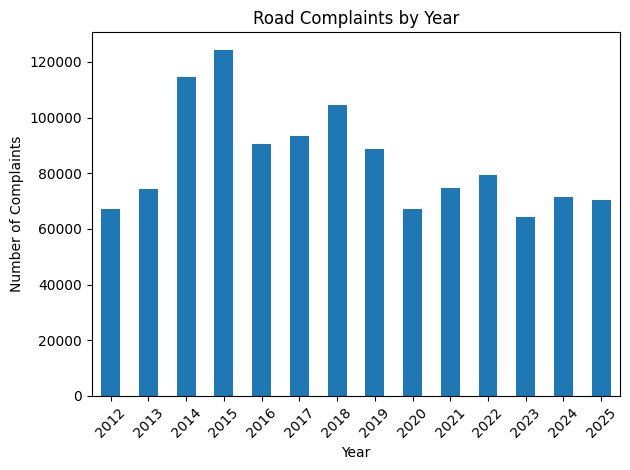

In [65]:
complaints_by_year = service_311["Year"].value_counts().sort_index()

display(complaints_by_year)

complaints_by_year.plot(kind="bar")
plt.title("Road Complaints by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Borough
QUEENS           381855
BROOKLYN         319990
MANHATTAN        204111
STATEN ISLAND    138580
BRONX            132923
UNSPECIFIED        1640
Name: count, dtype: int64

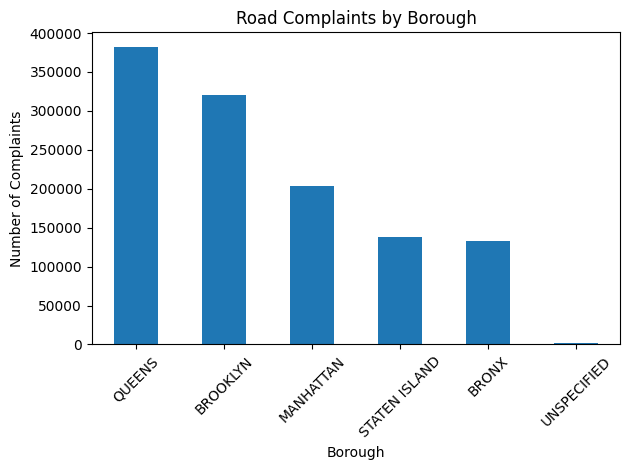

In [66]:
complaints_by_borough = service_311["Borough"].value_counts()

display(complaints_by_borough)

complaints_by_borough.plot(kind="bar")
plt.title("Road Complaints by Borough")
plt.xlabel("Borough")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Month
1      95175
2     114807
3     148413
4     122736
5     117678
6     114193
7      93694
8      88147
9      78297
10     73215
11     60381
12     77035
Name: count, dtype: int64

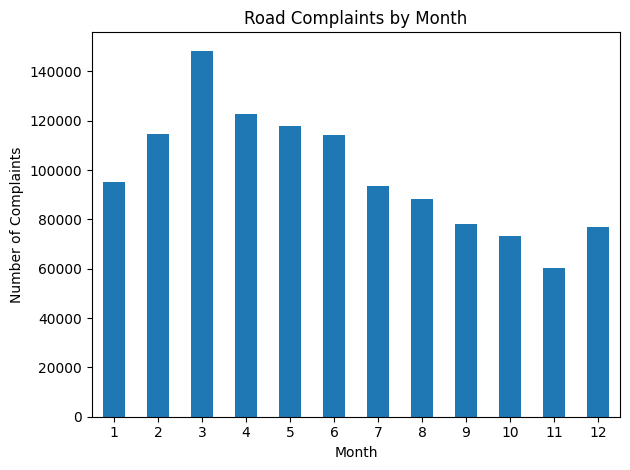

In [67]:
complaints_by_month = service_311["Month"].value_counts().sort_index()

display(complaints_by_month)

complaints_by_month.plot(kind="bar")
plt.title("Road Complaints by Month")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Problem Detail (formerly Descriptor)
POTHOLE                           708731
CAVE-IN                           128850
DEFECTIVE HARDWARE                 72750
FAILED STREET REPAIR               58991
ROUGH, PITTED OR CRACKED ROADS     58455
BLOCKED - CONSTRUCTION             46073
PLATE CONDITION - NOISY            28728
LINE/MARKING - FADED               18944
WEAR & TEAR                        16083
PLATE CONDITION - SHIFTED          11249
Name: count, dtype: int64

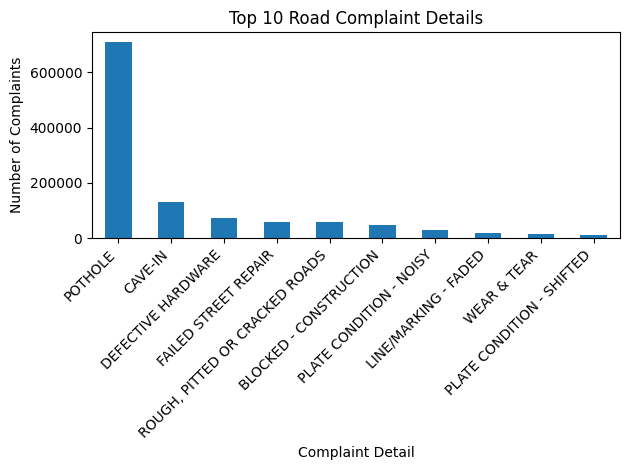

In [68]:
top_complaint_details = (
    service_311["Problem Detail (formerly Descriptor)"]
    .value_counts()
    .head(10)
)

display(top_complaint_details)

top_complaint_details.plot(kind="bar")
plt.title("Top 10 Road Complaint Details")
plt.xlabel("Complaint Detail")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Weather Trends


Month
1     32.021889
2     33.457628
3     40.843433
4     50.947857
5     61.189487
6     70.617679
7     76.994115
8     74.576786
9     68.345526
10    57.936934
11    45.320218
12    37.610234
Name: Avg_Temperature, dtype: float64

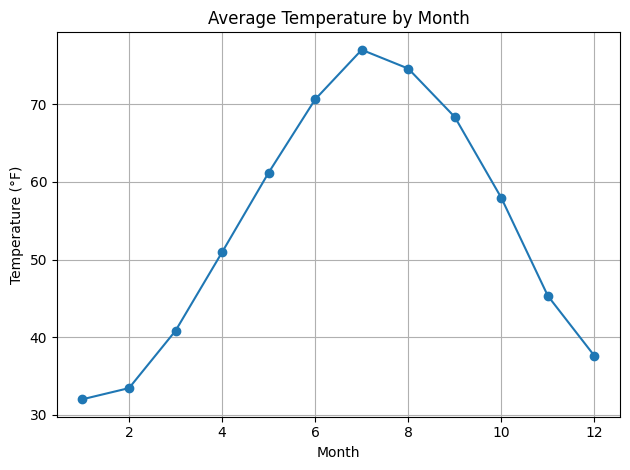

In [69]:
monthly_temperature = weather.groupby("Month")["Avg_Temperature"].mean()

display(monthly_temperature)

monthly_temperature.plot(kind="line", marker="o")
plt.title("Average Temperature by Month")
plt.xlabel("Month")
plt.ylabel("Temperature (°F)")
plt.grid(True)
plt.tight_layout()
plt.show()


Month
1     0.110161
2     0.123730
3     0.135880
4     0.125545
5     0.127691
6     0.132969
7     0.166359
8     0.124574
9     0.140676
10    0.148558
11    0.096290
12    0.143339
Name: Total_Precipitation, dtype: float64

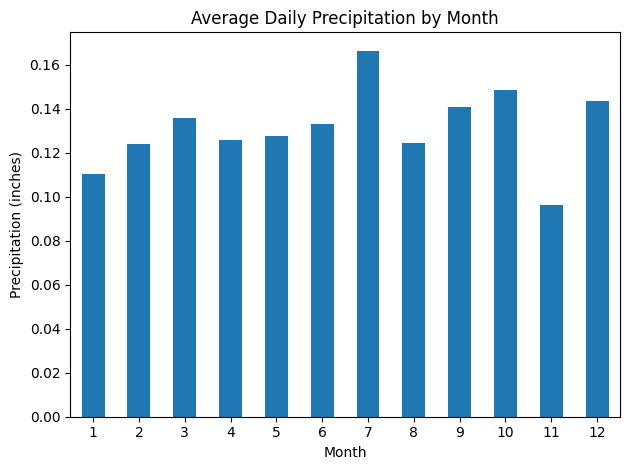

In [70]:
monthly_precipitation = weather.groupby("Month")["Total_Precipitation"].mean()

display(monthly_precipitation)

monthly_precipitation.plot(kind="bar")
plt.title("Average Daily Precipitation by Month")
plt.xlabel("Month")
plt.ylabel("Precipitation (inches)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Month
1     0.177530
2     0.309659
3     0.188972
4     0.013400
5     0.000256
6     0.000000
7     0.000000
8     0.000000
9     0.000000
10    0.000000
11    0.036769
12    0.109737
Name: Total_Snowfall, dtype: float64

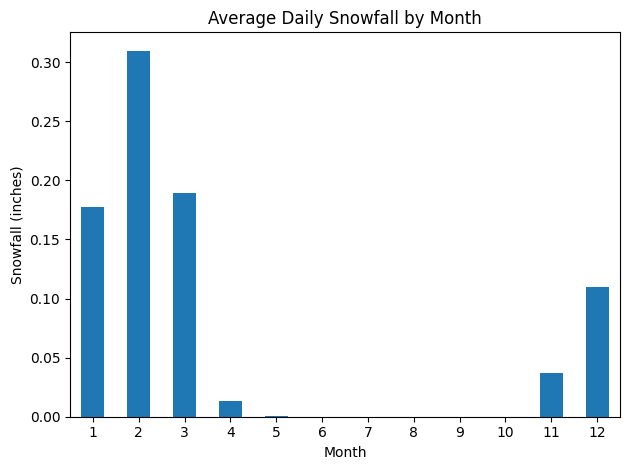

In [71]:
monthly_snowfall = weather.groupby("Month")["Total_Snowfall"].mean()

display(monthly_snowfall)

monthly_snowfall.plot(kind="bar")
plt.title("Average Daily Snowfall by Month")
plt.xlabel("Month")
plt.ylabel("Snowfall (inches)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Traffic Trends

Year
2012    5719.898133
2013    5181.615405
2014    6007.952261
2015    5798.609717
2016    5795.735206
2017    6465.101778
2018    5473.556238
2019    6287.014540
2020    5786.072329
2021    4540.610870
Name: Daily_Traffic_Volume, dtype: float64

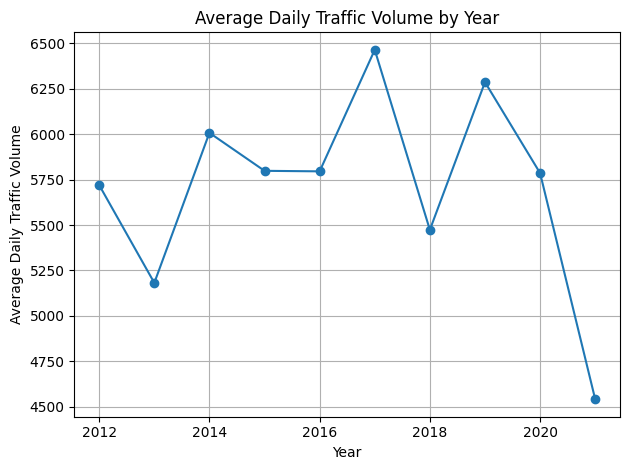

In [72]:
traffic_by_year = traffic.groupby("Year")["Daily_Traffic_Volume"].mean()

display(traffic_by_year)

traffic_by_year.plot(kind="line", marker="o")
plt.title("Average Daily Traffic Volume by Year")
plt.xlabel("Year")
plt.ylabel("Average Daily Traffic Volume")
plt.grid(True)
plt.tight_layout()
plt.show()

Street Name
COLUMBUS CIRCLE NB     15052.888889
ROGERS AVENUE          14265.814815
BOWERY                 14124.339286
BROOME STREET          13966.962963
PENNSYLVANIA AVENUE    13884.805556
BORINQUEN PLACE        13216.055556
9TH AVENUE             13003.777778
COLUMBUS AVE           12845.000000
2ND AVENUE             12727.444444
ROGERS AVE             12663.266667
Name: Daily_Traffic_Volume, dtype: float64

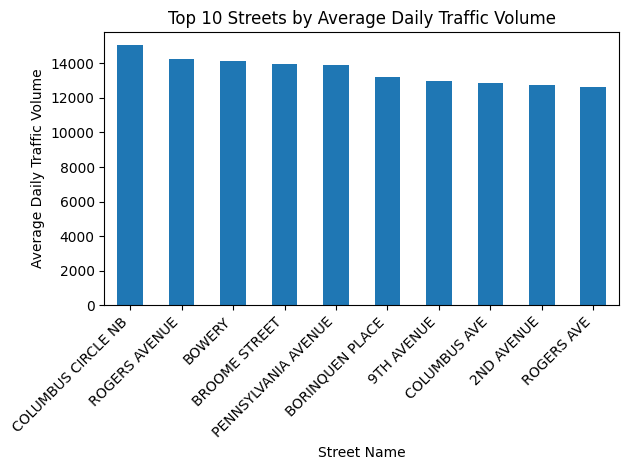

In [73]:
top_traffic_streets = (
    traffic.groupby("Street Name")["Daily_Traffic_Volume"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top_traffic_streets)

top_traffic_streets.plot(kind="bar")
plt.title("Top 10 Streets by Average Daily Traffic Volume")
plt.xlabel("Street Name")
plt.ylabel("Average Daily Traffic Volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Phase 1C Summary

Exploratory Data Analysis was performed to better understand the characteristics of each dataset. Complaint trends, weather conditions, traffic patterns, and data distributions were examined through summary statistics and visualizations. These insights guided feature selection and prepared the data for machine learning.